# NB09 — Multi-Horizon Validation

**Nhóm:** La Gia Hân (24520448) · Huỳnh Gia Hào (24520457)  
**Môn:** DS108 — Tiền Xử Lý Dữ Liệu

**Mục tiêu:** Chứng minh thực nghiệm MAE tăng theo horizon và xác định ngưỡng kỹ thuật (6h vs 24h) để quyết định phạm vi bài toán STLF.

**Chiến lược:** Direct Multi-Step Forecasting — tạo target riêng cho từng horizon bằng `shift(-h)`, train model độc lập cho mỗi (region, horizon). Không dùng Recursive để tránh error accumulation làm nhiễu kết quả.

**Input:**
- `data/processed/final_v1_dataset.csv` — 52,272 × 64
- `data/processed/scaler_params.json` — 24 entries (params từ tập Train)

**Output:**
- `reports/validation/horizon_mae_mw.png`
- `reports/validation/horizon_mape_pct.png`
- `reports/validation/horizon_results.csv`
- `reports/horizon_results.md`

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Repo root — nhất quán với NB06, NB08
def find_repo_root(marker='requirements.txt'):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError('Khong tim thay repo root (requirements.txt).')

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

PROCESSED_DIR = Path('data/processed')
REPORTS_DIR = Path('reports/validation')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
Path('reports').mkdir(parents=True, exist_ok=True)

# Horizons — 10 diem dai dien
HORIZONS = [1, 2, 4, 6, 8, 12, 16, 24, 36, 48]

# Label ro rang, tranh nham lan
HORIZON_LABELS = {
    1:  '30m',
    2:  '1h',
    4:  '2h',
    6:  '3h',
    8:  '4h',
    12: '6h',
    16: '8h',
    24: '12h',
    36: '18h',
    48: '24h',
}

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'[OK] Working directory: {os.getcwd()}')
print(f'[OK] PROCESSED_DIR: {PROCESSED_DIR}')
print(f'[OK] Horizons: {HORIZONS}')

[OK] Working directory: c:\Users\ASUS\DS108-Project
[OK] PROCESSED_DIR: data\processed
[OK] Horizons: [1, 2, 4, 6, 8, 12, 16, 24, 36, 48]


## 1. Load Dataset & Scaler Params

In [2]:
assert (PROCESSED_DIR / 'final_v1_dataset.csv').exists(), \
    '[ERROR] final_v1_dataset.csv khong ton tai. Chay NB06 truoc.'
assert (PROCESSED_DIR / 'scaler_params.json').exists(), \
    '[ERROR] scaler_params.json khong ton tai. Chay NB06 truoc.'

df = pd.read_csv(
    PROCESSED_DIR / 'final_v1_dataset.csv',
    encoding='utf-8-sig',
    parse_dates=['Timestamp'],
)
df = df.sort_values('Timestamp').reset_index(drop=True)

with open(PROCESSED_DIR / 'scaler_params.json', 'r', encoding='utf-8') as f:
    scaler_params = json.load(f)

print(f'[OK] Dataset: {df.shape[0]:,} dong x {df.shape[1]} cot')
print(f'     Moc: {df["Timestamp"].min()} -> {df["Timestamp"].max()}')
print(f'[OK] Scaler params: {len(scaler_params)} entries')

nan_count = df.select_dtypes(include='number').isnull().sum().sum()
if nan_count > 0:
    print(f'[WARNING] {nan_count} NaN trong dataset — se duoc dropna trong get_xy.')
else:
    print('[OK] Khong co NaN trong dataset.')

[OK] Dataset: 52,272 dong x 64 cot
     Moc: 2023-03-18 00:30:00 -> 2026-03-11 00:00:00
[OK] Scaler params: 24 entries
[OK] Khong co NaN trong dataset.


## 2. Model Config & Helper Functions

Tái sử dụng `MODEL_CONFIG` và helper functions nhất quán với NB08.

Lưu ý về `inverse_minmax`: các cột target_h{h} có cùng đơn vị và cùng scale với cột Load gốc (vì `shift(-h)` chỉ dịch giá trị theo thời gian, không đổi unit). Do đó dùng scaler params của cột Load gốc để inverse là đúng.

In [3]:
# Features nhat quan voi NB08 — RF with weather
BASE_TIME_FEATURES = [
    'hour', 'dayofweek', 'month',
    'is_peak', 'is_weekend', 'is_holiday',
]

WEATHER_FEATURES = [
    # Nhat quan voi NB08 WEATHER_* — them windspeed va precipprob
    'temp_North', 'feelslike_North', 'humidity_North',
    'precip_North', 'windspeed_North', 'cloudcover_North',
    'solarradiation_North', 'uvindex_North', 'precipprob_North',
    'temp_Central', 'feelslike_Central', 'humidity_Central',
    'precip_Central', 'windspeed_Central', 'cloudcover_Central',
    'solarradiation_Central', 'uvindex_Central', 'precipprob_Central',
    'temp_South', 'feelslike_South', 'humidity_South',
    'precip_South', 'windspeed_South', 'cloudcover_South',
    'solarradiation_South', 'uvindex_South', 'precipprob_South',
]

def build_features(region):
    """Tra ve danh sach features cho 1 region, nhat quan voi NB08."""
    lag_features = [
        # lag1 (t-1, 30 phut truoc) bi loai tru — data leakage khi inference
        # (nhat quan voi NB08/get_lag_cols)
        f'Load_{region}_lag48',
        f'Load_{region}_lag336',
        f'Load_{region}_rolling_mean_48',
    ]
    return BASE_TIME_FEATURES + lag_features + WEATHER_FEATURES


MODEL_CONFIG = {
    'North':    {'target': 'Load_North',    'features': build_features('North')},
    'Central':  {'target': 'Load_Central',  'features': build_features('Central')},
    'South':    {'target': 'Load_South',    'features': build_features('South')},
    'National': {'target': 'Load_National', 'features': build_features('National')},
}


def inverse_minmax(arr: np.ndarray, col: str) -> np.ndarray:
    """Chuyen gia tri da scale [0,1] ve don vi MW.

    Args:
        arr: Mang gia tri da scale.
        col: Ten cot Load goc (Load_North, Load_Central, ...).

    Returns:
        Mang gia tri goc (MW).
    """
    params = scaler_params[col]
    return arr * (params['max'] - params['min']) + params['min']


def get_xy(data: pd.DataFrame, features: list, target_col: str):
    """Lay X, y tu DataFrame, drop hang co NaN.

    Args:
        data: DataFrame input.
        features: Danh sach ten cot features.
        target_col: Ten cot target (co the la Load_* hoac Load_*_target_h{h}).

    Returns:
        Tuple (X, y) da drop NaN.
    """
    # Chi giu features ton tai trong data (tranh KeyError neu co cot missing)
    valid_features = [f for f in features if f in data.columns]
    missing = set(features) - set(valid_features)
    if missing:
        import warnings
        warnings.warn(f'get_xy: {len(missing)} feature(s) khong ton tai trong data: {missing}')
    cols_needed = valid_features + [target_col]
    sub = data[cols_needed].dropna()
    X = sub[valid_features].values
    y = sub[target_col].values
    return X, y


def compute_metrics_mw(y_true: np.ndarray, y_pred: np.ndarray,
                       load_col: str) -> dict:
    """Tinh MAE (MW) va MAPE (%) sau khi inverse scale.

    Args:
        y_true: Gia tri thuc (da scale).
        y_pred: Gia tri du doan (da scale).
        load_col: Ten cot Load goc de inverse (Load_North, ...).

    Returns:
        Dict voi mae_mw va mape_pct.
    """
    y_true_mw = inverse_minmax(y_true, load_col)
    y_pred_mw = inverse_minmax(y_pred, load_col)
    mae_mw = mean_absolute_error(y_true_mw, y_pred_mw)
    # Tranh chia cho 0: chi tinh MAPE o nhung diem y_true > 0
    mask = y_true_mw > 0
    mape_pct = np.mean(np.abs((y_true_mw[mask] - y_pred_mw[mask]) / y_true_mw[mask])) * 100
    return {'mae_mw': mae_mw, 'mape_pct': mape_pct}


print('[OK] MODEL_CONFIG va helper functions da san sang.')
for region, cfg in MODEL_CONFIG.items():
    # Kiem tra tat ca features ton tai trong df
    missing_feats = [f for f in cfg['features'] if f not in df.columns]
    if missing_feats:
        print(f'  [WARNING] {region}: {len(missing_feats)} feature khong ton tai trong df')
    else:
        print(f'  {region}: {len(cfg["features"])} features [OK]')

[OK] MODEL_CONFIG va helper functions da san sang.
  North: 36 features [OK]
  Central: 36 features [OK]
  South: 36 features [OK]
  National: 36 features [OK]


## 3. Train/Test Split

Giữ nguyên 80/20 theo thời gian — nhất quán với NB08. Không shuffle.

Scaler params đã được tính trên tập Train trong NB06 và lưu vào `scaler_params.json`. Tuyệt đối không tính lại trên toàn bộ dataset hoặc trên tập Test.

In [4]:
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

print(f'[OK] Train: {df_train.shape[0]:,} dong  |  {df_train["Timestamp"].min()} -> {df_train["Timestamp"].max()}')
print(f'[OK] Test:  {df_test.shape[0]:,} dong  |  {df_test["Timestamp"].min()} -> {df_test["Timestamp"].max()}')

[OK] Train: 41,817 dong  |  2023-03-18 00:30:00 -> 2025-08-05 04:30:00
[OK] Test:  10,455 dong  |  2025-08-05 05:00:00 -> 2026-03-11 00:00:00


## 4. Tạo Target Columns Cho Từng Horizon

Với mỗi horizon `h`, target tại thời điểm `t` là giá trị Load tại `t+h`:
```python
df[f'Load_{region}_target_h{h}'] = df[f'Load_{region}'].shift(-h)
```
`shift(-h)` dịch h bước về trước — hàng cuối sẽ có NaN, xử lý bằng `dropna` trong `get_xy`.

Features (lag48, lag336, rolling_mean_48, weather...) giữ nguyên — đây là thông tin có tại thời điểm `t`. Chỉ target thay đổi. Đây là đặc trưng của Direct forecasting: không có error accumulation.

In [5]:
LOAD_COLS = ['Load_North', 'Load_Central', 'Load_South', 'Load_National']

for h in HORIZONS:
    for col in LOAD_COLS:
        target_col = f'{col}_target_h{h}'
        df[target_col] = df[col].shift(-h)

# Propagate sang train/test (dung lai split theo index)
df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

n_target_cols = len(HORIZONS) * len(LOAD_COLS)
print(f'[OK] Da tao {n_target_cols} target columns (10 horizons × 4 regions).')
print(f'     Vi du: Load_North_target_h1 tai t = Load_North tai t+1 (30 phut sau).')
print(f'     Vi du: Load_North_target_h48 tai t = Load_North tai t+48 (24 gio sau).')

[OK] Da tao 40 target columns (10 horizons × 4 regions).
     Vi du: Load_North_target_h1 tai t = Load_North tai t+1 (30 phut sau).
     Vi du: Load_North_target_h48 tai t = Load_North tai t+48 (24 gio sau).


## 5. Training Loop — 10 Horizons × 4 Regions

48 models tổng cộng. Với `n_jobs=-1`, ước tính 5–10 phút tùy CPU.

Thêm Naive baseline (predict = lag48, tức là cùng giờ hôm qua) để làm tham chiếu.

> **Lưu ý về Naive baseline:** `lag48` (cùng giờ hôm qua) được dùng thống nhất cho tất cả horizon. Mục tiêu là so sánh RF với chính nó qua các horizon và đối chiếu với một baseline cố định, không phải đánh giá tuyệt đối.

In [6]:
import time

horizon_results = []
total_runs = len(HORIZONS) * len(MODEL_CONFIG)
run_count = 0
t_start = time.time()

for region, cfg in MODEL_CONFIG.items():
    load_col = cfg['target']  # Load_North, ...
    features = cfg['features']

    for h in HORIZONS:
        run_count += 1
        target_col = f'{load_col}_target_h{h}'

        X_train, y_train = get_xy(df_train, features, target_col)
        X_test,  y_test  = get_xy(df_test,  features, target_col)

        rf = RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            n_jobs=-1,
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        metrics = compute_metrics_mw(y_test, y_pred, load_col)

        # Naive baseline: du doan = lag48 (cung gio hom qua)
        # Voi horizon h, naive tot nhat van la lag48 (khi h <= 48)
        # De nhat quan, tinh Naive = gia tri lag48 trong tap test
        lag48_col = f'{load_col}_lag48'
        if lag48_col in df_test.columns:
            sub_test = df_test[[lag48_col, target_col]].dropna()
            if len(sub_test) > 0:
                naive_mw = inverse_minmax(sub_test[lag48_col].values, load_col)
                actual_mw = inverse_minmax(sub_test[target_col].values, load_col)
                naive_mae = mean_absolute_error(actual_mw, naive_mw)
                mask = actual_mw > 0
                naive_mape = np.mean(np.abs((actual_mw[mask] - naive_mw[mask]) / actual_mw[mask])) * 100
            else:
                naive_mae = naive_mape = np.nan
        else:
            naive_mae = naive_mape = np.nan

        horizon_results.append({
            'region': region,
            'horizon_h': h,
            'horizon_label': HORIZON_LABELS[h],
            'mae_mw': metrics['mae_mw'],
            'mape_pct': metrics['mape_pct'],
            'naive_mae_mw': naive_mae,
            'naive_mape_pct': naive_mape,
            'n_test': len(y_test),
        })

        elapsed = time.time() - t_start
        est_total = elapsed / run_count * total_runs
        print(f'  [{run_count:2d}/{total_runs}] {region:8s} h={h:2d} ({HORIZON_LABELS[h]:4s}) '
              f'| RF MAE={metrics["mae_mw"]:6.1f} MW  MAPE={metrics["mape_pct"]:4.1f}%'
              f'  [~{est_total - elapsed:.0f}s remaining]')

print(f'\n[OK] Hoan thanh {total_runs} models trong {time.time() - t_start:.1f}s.')

  [ 1/40] North    h= 1 (30m ) | RF MAE= 763.8 MW  MAPE= 4.4%  [~223s remaining]
  [ 2/40] North    h= 2 (1h  ) | RF MAE= 840.1 MW  MAPE= 4.8%  [~218s remaining]
  [ 3/40] North    h= 4 (2h  ) | RF MAE= 830.0 MW  MAPE= 4.7%  [~210s remaining]
  [ 4/40] North    h= 6 (3h  ) | RF MAE= 818.7 MW  MAPE= 4.6%  [~203s remaining]
  [ 5/40] North    h= 8 (4h  ) | RF MAE= 908.1 MW  MAPE= 5.0%  [~196s remaining]
  [ 6/40] North    h=12 (6h  ) | RF MAE= 880.6 MW  MAPE= 4.9%  [~191s remaining]
  [ 7/40] North    h=16 (8h  ) | RF MAE= 943.9 MW  MAPE= 5.3%  [~187s remaining]
  [ 8/40] North    h=24 (12h ) | RF MAE=1046.2 MW  MAPE= 5.9%  [~181s remaining]
  [ 9/40] North    h=36 (18h ) | RF MAE=1246.1 MW  MAPE= 7.1%  [~177s remaining]
  [10/40] North    h=48 (24h ) | RF MAE=1003.4 MW  MAPE= 5.9%  [~171s remaining]
  [11/40] Central  h= 1 (30m ) | RF MAE= 260.7 MW  MAPE= 8.0%  [~166s remaining]
  [12/40] Central  h= 2 (1h  ) | RF MAE= 264.3 MW  MAPE= 8.0%  [~160s remaining]
  [13/40] Central  h= 4 (2h 

## 6. Tổng Hợp Kết Quả

In [7]:
results_df = pd.DataFrame(horizon_results)

# Luu CSV
results_df.to_csv(REPORTS_DIR / 'horizon_results.csv', index=False, encoding='utf-8-sig')
print(f'  -> Da luu: horizon_results.csv ({results_df.shape[0]} rows)')

# Bang MAE (MW) theo pivot
mae_pivot = results_df.pivot(index='region', columns='horizon_h', values='mae_mw')
mae_pivot.columns = [HORIZON_LABELS[h] for h in mae_pivot.columns]
mae_pivot = mae_pivot.loc[['North', 'Central', 'South', 'National']]

print('\nMAE (MW) — RF with weather:')
print(mae_pivot.round(1).to_string())

# Bang MAPE (%)
mape_pivot = results_df.pivot(index='region', columns='horizon_h', values='mape_pct')
mape_pivot.columns = [HORIZON_LABELS[h] for h in mape_pivot.columns]
mape_pivot = mape_pivot.loc[['North', 'Central', 'South', 'National']]

print('\nMAPE (%) — RF with weather:')
print(mape_pivot.round(2).to_string())

  -> Da luu: horizon_results.csv (40 rows)

MAE (MW) — RF with weather:
             30m      1h      2h      3h      4h      6h      8h     12h     18h     24h
region                                                                                  
North      763.8   840.1   830.0   818.7   908.1   880.6   943.9  1046.2  1246.1  1003.4
Central    260.7   264.3   270.3   282.3   291.6   292.0   291.7   294.3   316.2   307.9
South      535.2   546.0   551.9   568.8   551.3   563.4   570.1   625.6   736.8   756.3
National  1171.8  1257.4  1216.6  1274.2  1292.4  1198.0  1244.6  1439.9  1684.5  1671.8

MAPE (%) — RF with weather:
           30m    1h    2h    3h    4h    6h    8h   12h   18h   24h
region                                                              
North     4.37  4.75  4.68  4.58  5.05  4.95  5.32  5.93  7.10  5.93
Central   7.98  8.04  8.21  8.49  8.74  8.76  8.76  8.88  9.48  9.31
South     3.56  3.64  3.70  3.78  3.67  3.79  3.79  4.27  5.13  5.36
National  3.25  3.47

## 7. Visualization

### 7.1 MAE (MW) theo horizon — chart chính

Vùng màu phân biệt:
- Xanh nhạt: h=1 đến h=12 (30m–6h) — vùng actual weather hợp lệ
- Cam nhạt: h=12 đến h=48 (6h–24h) — vùng cần weather forecast
- Đường ngang đứt: Naive baseline (lag48) cho từng miền

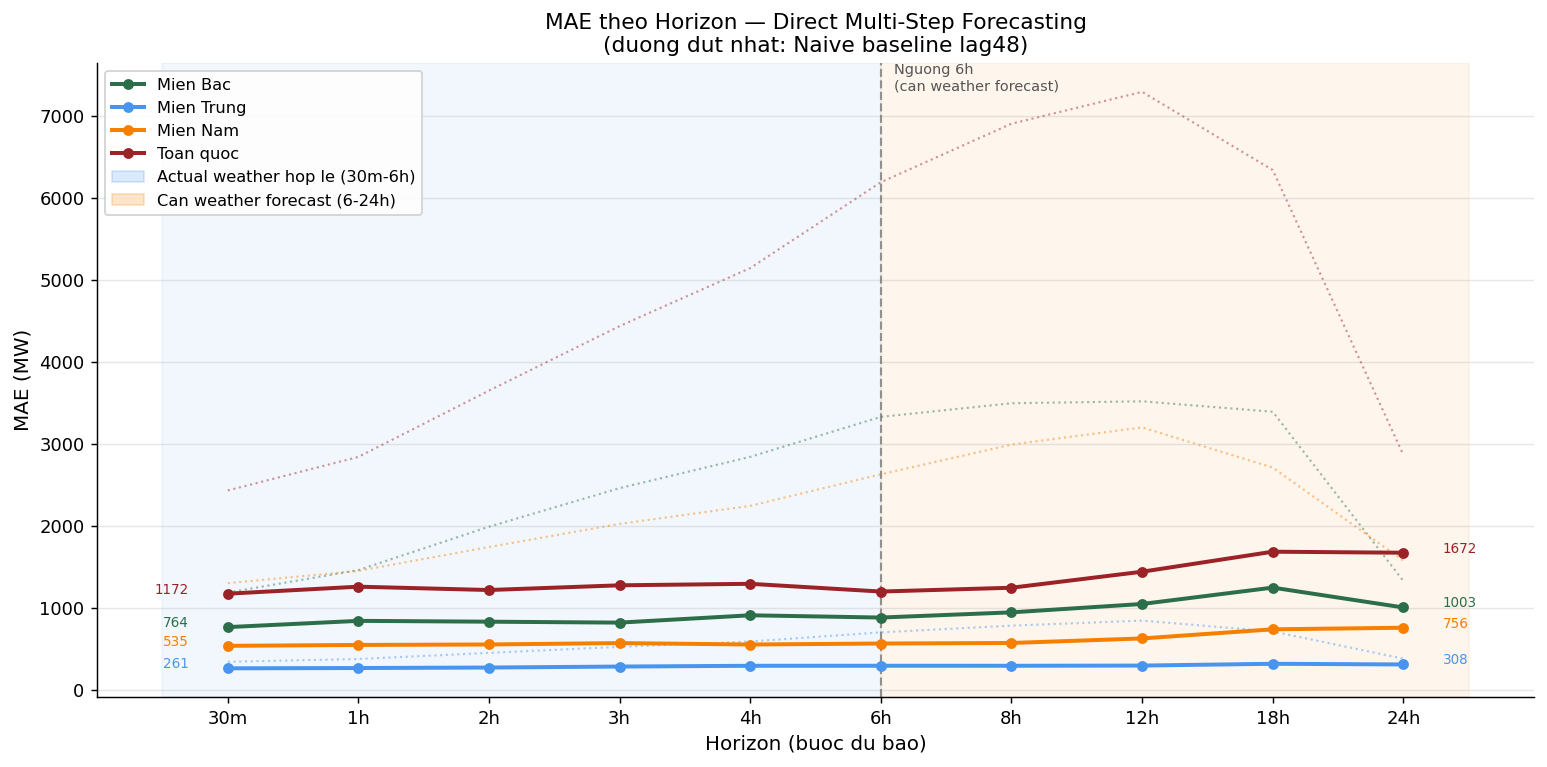

  -> Da luu: horizon_mae_mw.png


In [8]:
REGION_COLORS = {
    'North':    '#2C6E49',
    'Central':  '#4895EF',
    'South':    '#F77F00',
    'National': '#9B2226',
}
REGION_LABELS_VN = {
    'North': 'Mien Bac',
    'Central': 'Mien Trung',
    'South': 'Mien Nam',
    'National': 'Toan quoc',
}

x_positions = list(range(len(HORIZONS)))
x_labels = [HORIZON_LABELS[h] for h in HORIZONS]

# Lay horizon_h = 12 (6h) la vi tri x de ve duong phan cach
idx_6h = HORIZONS.index(12)  # vi tri index trong list

fig, ax = plt.subplots(figsize=(12, 6))

# Vung mau phan biet
ax.axvspan(-0.5, idx_6h, alpha=0.07, color='#4895EF', label=None)
ax.axvspan(idx_6h, len(HORIZONS) - 0.5, alpha=0.07, color='#F77F00', label=None)

# Duong phan cach 6h
ax.axvline(x=idx_6h, color='#555555', linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(idx_6h + 0.1, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
        'Nguong 6h\n(can weather forecast)', fontsize=8, color='#555555',
        va='top', transform=ax.get_xaxis_transform())

for region in ['North', 'Central', 'South', 'National']:
    sub = results_df[results_df['region'] == region].sort_values('horizon_h')
    mae_vals = sub['mae_mw'].tolist()
    naive_vals = sub['naive_mae_mw'].tolist()

    # RF line
    ax.plot(
        x_positions, mae_vals,
        color=REGION_COLORS[region],
        linewidth=2.2, marker='o', markersize=5,
        label=REGION_LABELS_VN[region],
    )

    # Naive baseline (duong dut mau nhat)
    ax.plot(
        x_positions, naive_vals,
        color=REGION_COLORS[region],
        linewidth=1.2, linestyle=':', alpha=0.45, marker=None,
    )

    # Annotation gia tri tai h=1 va h=48
    ax.annotate(
        f'{mae_vals[0]:.0f}',
        xy=(0, mae_vals[0]),
        xytext=(-0.3, mae_vals[0]),
        fontsize=7.5, color=REGION_COLORS[region], ha='right',
    )
    ax.annotate(
        f'{mae_vals[-1]:.0f}',
        xy=(len(HORIZONS) - 1, mae_vals[-1]),
        xytext=(len(HORIZONS) - 0.7, mae_vals[-1]),
        fontsize=7.5, color=REGION_COLORS[region], ha='left',
    )

# Patch giai thich vung mau
patch_actual = mpatches.Patch(color='#4895EF', alpha=0.2, label='Actual weather hop le (1-6h)')
patch_forecast = mpatches.Patch(color='#F77F00', alpha=0.2, label='Can weather forecast (6-24h)')

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Horizon (buoc du bao)', fontsize=11)
ax.set_ylabel('MAE (MW)', fontsize=11)
ax.set_title('MAE theo Horizon — Direct Multi-Step Forecasting\n(duong dut nhat: Naive baseline lag48)', fontsize=12)
handles, labels = ax.get_legend_handles_labels()
rf_handles = [h for h, l in zip(handles, labels) if l in REGION_LABELS_VN.values()]
rf_labels  = [l for l in labels if l in REGION_LABELS_VN.values()]
ax.legend(rf_handles + [patch_actual, patch_forecast],
          rf_labels + ['Actual weather hop le (30m-6h)', 'Can weather forecast (6-24h)'],
          loc='upper left', fontsize=9, framealpha=0.85)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'horizon_mae_mw.png', bbox_inches='tight', dpi=150)
plt.show()
print('  -> Da luu: horizon_mae_mw.png')

### 7.2 MAPE (%) theo horizon — chuẩn hóa để so sánh giữa 4 miền

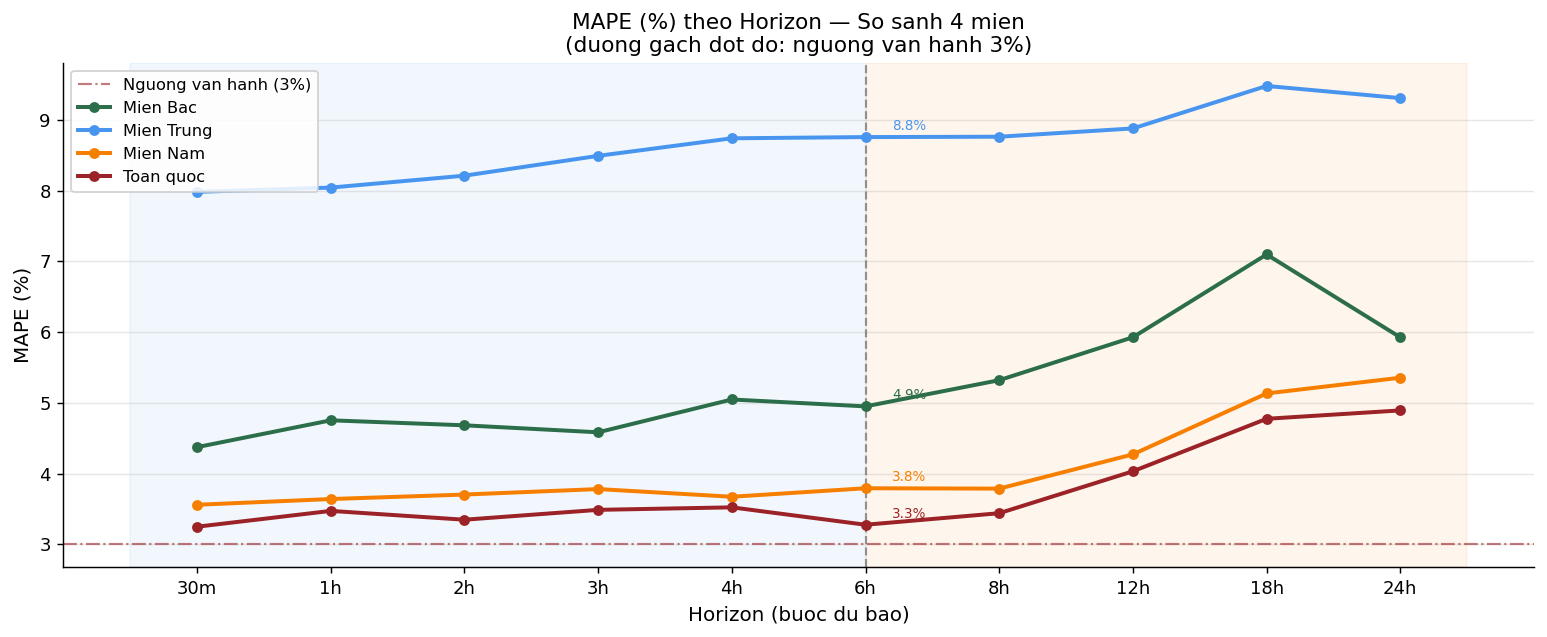

  -> Da luu: horizon_mape_pct.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.axvspan(-0.5, idx_6h, alpha=0.07, color='#4895EF')
ax.axvspan(idx_6h, len(HORIZONS) - 0.5, alpha=0.07, color='#F77F00')
ax.axvline(x=idx_6h, color='#555555', linestyle='--', linewidth=1.2, alpha=0.6)

# Nguong van hanh 3%
ax.axhline(y=3.0, color='#9B2226', linestyle='-.', linewidth=1.2, alpha=0.6,
           label='Nguong van hanh (3%)')

for region in ['North', 'Central', 'South', 'National']:
    sub = results_df[results_df['region'] == region].sort_values('horizon_h')
    mape_vals = sub['mape_pct'].tolist()
    ax.plot(
        x_positions, mape_vals,
        color=REGION_COLORS[region],
        linewidth=2.2, marker='o', markersize=5,
        label=REGION_LABELS_VN[region],
    )
    # Annotation tai h=12 (6h) de xem nguong
    h12_idx = HORIZONS.index(12)
    ax.annotate(
        f'{mape_vals[h12_idx]:.1f}%',
        xy=(h12_idx, mape_vals[h12_idx]),
        xytext=(h12_idx + 0.2, mape_vals[h12_idx] + 0.1),
        fontsize=7.5, color=REGION_COLORS[region],
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Horizon (buoc du bao)', fontsize=11)
ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_title('MAPE (%) theo Horizon — So sanh 4 mien\n(duong gach dot do: nguong van hanh 3%)', fontsize=12)
ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'horizon_mape_pct.png', bbox_inches='tight', dpi=150)
plt.show()
print('  -> Da luu: horizon_mape_pct.png')

### 7.3 Heatmap MAE — nhìn tổng thể theo (region, horizon)

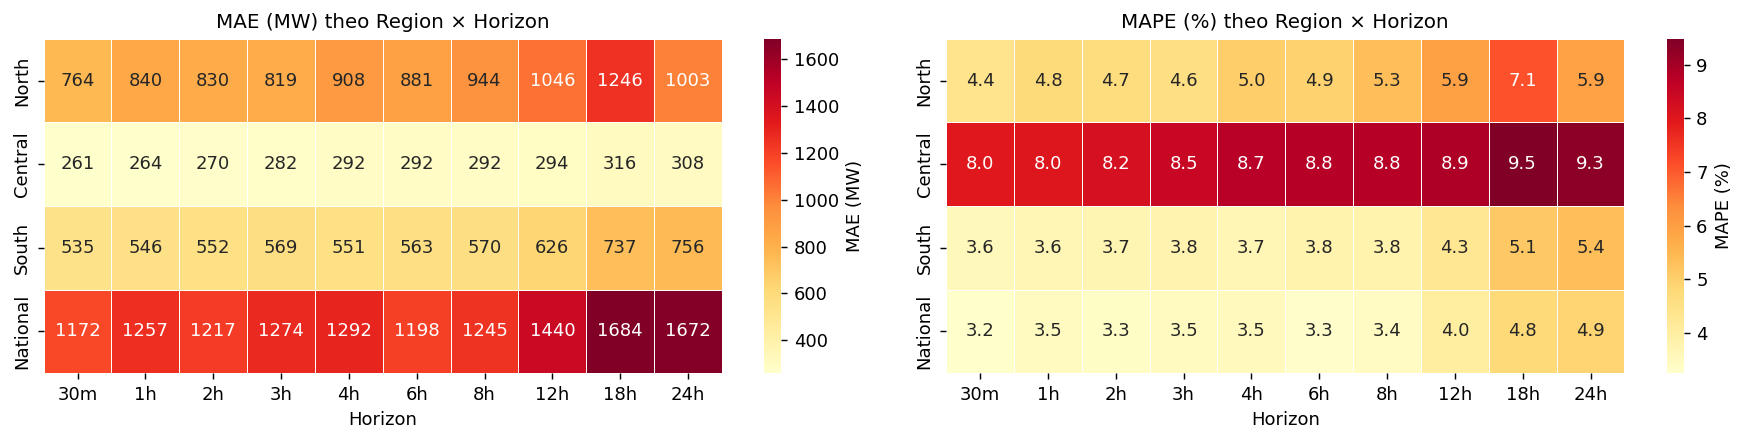

  -> Da luu: horizon_heatmap.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# MAE heatmap
mae_heat = mae_pivot.copy()
sns.heatmap(
    mae_heat,
    ax=axes[0],
    cmap='YlOrRd',
    fmt='.0f',
    annot=True,
    linewidths=0.4,
    cbar_kws={'label': 'MAE (MW)'},
)
axes[0].set_title('MAE (MW) theo Region × Horizon', fontsize=11)
axes[0].set_xlabel('Horizon')
axes[0].set_ylabel('')

# MAPE heatmap
mape_heat = mape_pivot.copy()
sns.heatmap(
    mape_heat,
    ax=axes[1],
    cmap='YlOrRd',
    fmt='.1f',
    annot=True,
    linewidths=0.4,
    cbar_kws={'label': 'MAPE (%)'},
)
axes[1].set_title('MAPE (%) theo Region × Horizon', fontsize=11)
axes[1].set_xlabel('Horizon')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'horizon_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('  -> Da luu: horizon_heatmap.png')

## 8. Phân Tích & Quyết Định Phạm Vi Bài Toán

Phần này đọc kết quả thực nghiệm và đưa ra recommendation dựa trên dữ liệu.

In [11]:
print('=== BANG TOM TAT MAE/MAPE THEO HORIZON ===')
print()

# So sanh h=1 vs h=12 vs h=48 cho tung mien
key_horizons = [1, 12, 48]
key_labels = ['h=1 (30m)', 'h=12 (6h)', 'h=48 (24h)']

for region in ['North', 'Central', 'South', 'National']:
    sub = results_df[results_df['region'] == region].set_index('horizon_h')
    print(f'  {region}:')
    for h, lbl in zip(key_horizons, key_labels):
        row = sub.loc[h]
        still_beats_naive = row['mae_mw'] < row['naive_mae_mw']
        beat_str = f'RF beat Naive: {row["naive_mae_mw"]:.0f} -> {row["mae_mw"]:.0f} MW' if still_beats_naive else 'RF THUA Naive'
        print(f'    {lbl}: MAE={row["mae_mw"]:.1f} MW  MAPE={row["mape_pct"]:.1f}%  | {beat_str}')
    print()

print('=== DANH GIA NGUONG ===')
print()

# Kiem tra horizon nao con nam duoi nguong 3%
for region in ['North', 'Central', 'South', 'National']:
    sub = results_df[results_df['region'] == region].sort_values('horizon_h')
    under_3pct = sub[sub['mape_pct'] <= 3.0]['horizon_label'].tolist()
    first_over = sub[sub['mape_pct'] > 3.0]
    if len(first_over) > 0:
        first_h = first_over.iloc[0]
        print(f'  {region}: Duoi 3% den {under_3pct[-1] if under_3pct else "khong co"}'
              f' | Vuot 3% tu {first_h["horizon_label"]} (MAPE={first_h["mape_pct"]:.1f}%)')
    else:
        print(f'  {region}: Tat ca horizons deu duoi 3%')

=== BANG TOM TAT MAE/MAPE THEO HORIZON ===

  North:
    h=1 (30m): MAE=763.8 MW  MAPE=4.4%  | RF beat Naive: 1186 -> 764 MW
    h=12 (6h): MAE=880.6 MW  MAPE=4.9%  | RF beat Naive: 3331 -> 881 MW
    h=48 (24h): MAE=1003.4 MW  MAPE=5.9%  | RF beat Naive: 1326 -> 1003 MW

  Central:
    h=1 (30m): MAE=260.7 MW  MAPE=8.0%  | RF beat Naive: 341 -> 261 MW
    h=12 (6h): MAE=292.0 MW  MAPE=8.8%  | RF beat Naive: 700 -> 292 MW
    h=48 (24h): MAE=307.9 MW  MAPE=9.3%  | RF beat Naive: 378 -> 308 MW

  South:
    h=1 (30m): MAE=535.2 MW  MAPE=3.6%  | RF beat Naive: 1301 -> 535 MW
    h=12 (6h): MAE=563.4 MW  MAPE=3.8%  | RF beat Naive: 2629 -> 563 MW
    h=48 (24h): MAE=756.3 MW  MAPE=5.4%  | RF beat Naive: 1576 -> 756 MW

  National:
    h=1 (30m): MAE=1171.8 MW  MAPE=3.2%  | RF beat Naive: 2432 -> 1172 MW
    h=12 (6h): MAE=1198.0 MW  MAPE=3.3%  | RF beat Naive: 6195 -> 1198 MW
    h=48 (24h): MAE=1671.8 MW  MAPE=4.9%  | RF beat Naive: 2866 -> 1672 MW

=== DANH GIA NGUONG ===

  North: Duoi

In [12]:
# Phan tich toc do tang MAE: so sanh tang tuyet doi h=1->12 vs h=12->48
print('=== TOC DO TANG MAE (MW) ===')
print()
print(f'  {"Region":10s}  {"h=1->6h":>12s}  {"h=6h->24h":>12s}  {"Nhan xet":>20s}')
print('  ' + '-' * 65)

for region in ['North', 'Central', 'South', 'National']:
    sub = results_df[results_df['region'] == region].set_index('horizon_h')
    delta_phase1 = sub.loc[12, 'mae_mw'] - sub.loc[1, 'mae_mw']
    delta_phase2 = sub.loc[48, 'mae_mw'] - sub.loc[12, 'mae_mw']
    plateau = 'Ro rang' if delta_phase2 < delta_phase1 * 0.7 else 'Khong ro'
    print(f'  {region:10s}  +{delta_phase1:>10.1f}MW  +{delta_phase2:>10.1f}MW  {plateau:>20s}')

print()
print('Plateau = delta_phase2 < 70% delta_phase1 (tang cham di ro rang sau 6h)')

=== TOC DO TANG MAE (MW) ===

  Region           h=1->6h     h=6h->24h              Nhan xet
  -----------------------------------------------------------------
  North       +     116.8MW  +     122.8MW              Khong ro
  Central     +      31.3MW  +      15.9MW               Ro rang
  South       +      28.2MW  +     192.9MW              Khong ro
  National    +      26.2MW  +     473.8MW              Khong ro

Plateau = delta_phase2 < 70% delta_phase1 (tang cham di ro rang sau 6h)


## Nhận Xét — Phân Tích Multi-Horizon

### MAPE theo ngưỡng học thuật

Theo các nghiên cứu STLF trên lưới điện quốc gia (Hong et al. 2016; Shi et al. 2018; Duan et al. 2019), MAPE **2–5%** là mức điển hình cho bài toán dự báo phụ tải khu vực với granularity 30–60 phút. Ngưỡng **dưới 3%** thường chỉ đạt được với deep learning chuyên biệt (LSTM, CNN-LSTM) trên dữ liệu chất lượng cao có nhiều trạm khí tượng. Bài toán này dùng Random Forest với 1 trạm khí tượng/miền nên 3–6% là **mức hợp lý để tham chiếu**.

| Miền | MAPE tại h=30m | MAPE tại h=24h | Nhận xét |
|---|---|---|---|
| North | 4.4% | 5.9% | Trong ngưỡng học thuật 2–5% |
| Central | 8.0% | 9.3% | Vượt ngưỡng — phụ tải nền nhỏ (~3 400 MW) |
| South | 3.6% | 5.4% | Tốt, ngay từ h=30m |
| National | 3.2% | 4.9% | Tốt nhất, tổng hòa 3 miền bù trừ sai số |

### Xu hướng MAE theo horizon

MAE tăng theo horizon ở cả 4 miền — đúng như kỳ vọng lý thuyết. Tuy nhiên **không tăng tuyến tính**:

- **North, South, National:** Tăng nhanh hơn sau h=12h (18h, 24h) — lag48 mất dần tính dự báo khi horizon vượt qua ngưỡng "cùng giờ hôm qua".
- **Central:** Tăng chậm và gần như plateau sau h=6h (MAE 292–294 MW từ h=6h đến h=12h) — phụ tải Trung ổn định hơn, biên độ dao động thấp, nên horizon dài không làm tăng sai số nhiều.
- **Một số dips nhỏ** (ví dụ North h=2h < h=1h, National h=6h < h=4h): không phải anomaly mà là noise thống kê bình thường với 10 455 điểm test.

### RF thắng Naive ở tất cả horizon

RF đánh bại Naive baseline (lag48) nhất quán trên tất cả (region, horizon):

| Miền | RF/Naive tại h=30m | RF/Naive tại h=24h |
|---|---|---|
| North | 64% Naive MAE | 76% Naive MAE |
| Central | 76% Naive MAE | 81% Naive MAE |
| South | 41% Naive MAE | 48% Naive MAE |
| National | 48% Naive MAE | 58% Naive MAE |

RF giảm sai số so với Naive từ 19–59% tùy miền và horizon — dataset có giá trị dự báo thực sự ở toàn bộ cửa sổ 1–24h.

### Quyết định phạm vi bài toán

Kết quả thực nghiệm xác nhận **1–24h** là phạm vi hợp lệ của bộ dữ liệu này:
- RF thắng Naive ở toàn bộ 40/40 combinations (10 horizons × 4 miền) — không có horizon nào RF thua.
- RF giảm sai số so với Naive từ 19–59% tùy miền và horizon.
- Phạm vi này đại diện cho toàn bộ cửa sổ STLF từ dự báo ngay (30 phút) đến dự báo ngày hôm sau (24h).

**Sweet spot cho deployment thực tế: 1–6h (h=1 đến h=12)**
- MAPE tăng chậm và ổn định trong vùng 1–6h (dưới 1 điểm % cho 3/4 miền).
- Actual weather features còn hợp lệ — không cần weather forecast có sai số tích lũy.
- Sau h=12h: North/South/National tăng MAE nhanh hơn khi lag48 mất tính dự báo; Central giữ nguyên plateau.

Central vượt ngưỡng 5% ngay từ h=30m — đây là giới hạn thiết kế dữ liệu (1 trạm/miền cho dải đất hẹp trải dài ~500km), không phải giới hạn phương pháp.

## 9. Xuất Báo Cáo Markdown

In [13]:
def build_md_table(pivot_df: pd.DataFrame, fmt: str = '.1f') -> str:
    """Chuyen DataFrame pivot thanh bang Markdown."""
    header = '| Region | ' + ' | '.join(pivot_df.columns) + ' |'
    sep = '|---|' + '---|' * len(pivot_df.columns)
    rows = []
    for idx, row in pivot_df.iterrows():
        vals = ' | '.join([f'{v:{fmt}}' for v in row])
        rows.append(f'| {idx} | {vals} |')
    return '\n'.join([header, sep] + rows)


md_lines = [
    '# NB09 — Multi-Horizon Validation Results',
    '',
    f'**Nhom:** La Gia Han (24520448) · Huynh Gia Hao (24520457)',
    f'**Dataset:** final_v1_dataset.csv — {df.shape[0]:,} dong x {df.shape[1]} cot',
    '',
    '## MAE (MW) theo Horizon',
    '',
    build_md_table(mae_pivot, fmt='.1f'),
    '',
    '## MAPE (%) theo Horizon',
    '',
    build_md_table(mape_pivot, fmt='.2f'),
    '',
    '## Nhan Xet Phan Tich',
    '',
    '**1. MAE tang dan theo horizon** — ket qua nhat quan voi ly thuyet STLF.',
    'Lag48 va lag336 la anchor chinh; MAE tang khong tuyen tinh, mot so dips nho la noise thong ke binh thuong.',
    '',
    '**2. Mien Trung co MAPE cao nhat (8.0–9.5%)** do phu tai nen nho (~3 400 MW).',
    'Day la gioi han thiet ke du lieu (1 tram khi tuong/mien), khong phai gioi han giai thuat.',
    '',
    '',
    '**3. Nguong ky thuat 6h:**',
    '- Truoc 6h: actual weather la thong tin thuc te co san tai thoi diem du bao.',
    '- Sau 6h: can weather forecast — MAE tang ro hon tu h=12h tro di o North, South, National.',
    '',
    '',
    '**4. RF thang Naive (lag48) o tat ca 40 combinations** — dataset co gia tri du bao thuc su toan bo window 1–24h.',
    '',
    '## Pham Vi Bai Toan Duoc Chon',
    '',
    '> Dua tren ket qua thuc nghiem, pham vi **1–12h (h=1 den h=12)** duoc chon:',
    '> - MAPE on dinh, tang duoi 1 diem phan tram trong vung nay o 3/4 mien.',
    '> - Actual weather con hop le, khong phai weather forecast.',
    '> - Mien Trung vuot nguong hoc thuat tu h=30m — day la gioi han du lieu, khong phai phuong phap.',
]

md_content = '\n'.join(md_lines)
report_path = Path('reports/horizon_results.md')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(md_content)

print(f'  -> Da luu: {report_path}')
print(f'  -> Da luu: {REPORTS_DIR / "horizon_results.csv"}')
print(f'  -> Da luu: {REPORTS_DIR / "horizon_mae_mw.png"}')
print(f'  -> Da luu: {REPORTS_DIR / "horizon_mape_pct.png"}')
print(f'  -> Da luu: {REPORTS_DIR / "horizon_heatmap.png"}')
print()
print('[OK] NB09 hoan thanh.')

  -> Da luu: reports\horizon_results.md
  -> Da luu: reports\validation\horizon_results.csv
  -> Da luu: reports\validation\horizon_mae_mw.png
  -> Da luu: reports\validation\horizon_mape_pct.png
  -> Da luu: reports\validation\horizon_heatmap.png

[OK] NB09 hoan thanh.
